# Premier League Salary Tier Classification (2024–25)

## Problem statement
We want to **classify Premier League outfield players (exclude GKs)** into **three salary tiers** using only a single player performance stats CSV (FBRef “standard stats”) plus an external salary CSV.

### Salary tiers (labels) — defined *within each position group*
Position groups: **FW, MF, DF**

- **Low**: bottom ~33rd percentile of annual wage within that position group
- **Medium**: 33rd–66th percentile within that position group
- **High**: top ~33rd percentile within that position group

### Data sources (place in `data/` before running)
- `data/Squad_PlayerStats__stats_standard.csv` (FBRef standard stats export)
- `data/pl_salaries_2024_25.csv` with columns `player`, `squad`, `weekly_wage_gbp`

### Important data handling note
If a player appears multiple times for different squads (mid-season transfer), we **keep the single row with the most minutes** so each player has one record.

### Output
This notebook trains multiple models to predict salary tier from performance features, then exports per-player predictions to `output/player_salary_classifications.csv`.


In [2]:
import os
import re
import random
import unicodedata
from dataclasses import dataclass
from typing import Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from rapidfuzz import fuzz, process

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
    cross_val_score,
    RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


CONFIG = {
    "stats_path": "data/Squad_PlayerStats__stats_standard.csv",
    "salary_path": "data/pl_salaries_2024_25.csv",
    "output_path": "output/player_salary_classifications.csv",
    "min_minutes": 450,
    "random_state": 42,
    "fuzzy_threshold": 85,
    "cv_folds": 5,
}

# Intent: make results reproducible across runs.
random.seed(CONFIG["random_state"])
np.random.seed(CONFIG["random_state"])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


In [3]:
def _flatten_fbref_columns(cols: pd.Index) -> list[str]:
    """Flatten FBRef-style multi-index columns.

    Intent: Kaggle exports sometimes include 2-row headers; this normalizes them.
    """
    if not isinstance(cols, pd.MultiIndex):
        return [str(c).strip().lower() for c in cols]

    flat = []
    for a, b in cols.to_list():
        a = "" if str(a).startswith("Unnamed") else str(a).strip()
        b = "" if str(b).startswith("Unnamed") else str(b).strip()
        name = "_".join([p for p in [a, b] if p])
        flat.append(name.strip().lower())
    return flat


def _canonicalize_colname(name: str) -> str:
    """Normalize a column name to a safe canonical form."""
    s = str(name).strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s


def load_fbref_standard_stats(path: str) -> pd.DataFrame:
    """Load stats CSV and normalize column names.

    Handles:
    - 2-row multi-level headers (FBRef artifact)
    - single-row headers (common Kaggle export)
    - duplicate header rows embedded as data (player == 'Player')
    """

    def _read_single_header() -> pd.DataFrame:
        d = pd.read_csv(path, header=0)
        d.columns = [_canonicalize_colname(c) for c in d.columns]
        return d

    # Try multi-index first, but detect the common failure mode where the first data row
    # is mistakenly consumed as header level 2 (e.g., columns like 'player_max_aarons').
    try:
        df = pd.read_csv(path, header=[0, 1])
        df.columns = _flatten_fbref_columns(df.columns)
        df.columns = [_canonicalize_colname(c) for c in df.columns]

        # Heuristic: if canonical 'player' is missing but we see 'player_<name>' style
        # columns, we likely mis-read a single-header file as multi-header.
        if ("player" not in df.columns) and any(c.startswith("player_") for c in df.columns):
            df = _read_single_header()

    except (ValueError, pd.errors.ParserError, UnicodeDecodeError):
        df = _read_single_header()

    # Intent: FBRef/Kaggle exports sometimes repeat the header row within the file.
    if "player" in df.columns:
        df = df[df["player"].astype(str).str.strip() != "Player"].copy()

    print("Normalized columns (stats):")
    print(df.columns.tolist())

    return df


stats_raw = load_fbref_standard_stats(CONFIG["stats_path"])
stats_raw.head()


Normalized columns (stats):
['rk', 'player', 'nation', 'pos', 'squad', 'age', 'born', 'playing_time_mp', 'playing_time_starts', 'playing_time_min', 'playing_time_90s', 'performance_gls', 'performance_ast', 'performance_g_a', 'performance_g_pk', 'performance_pk', 'performance_pkatt', 'performance_crdy', 'performance_crdr', 'per_90_minutes_gls', 'per_90_minutes_ast', 'per_90_minutes_g_a', 'per_90_minutes_g_pk', 'per_90_minutes_g_a_pk', 'matches']


,rk,player,nation,pos,squad,age,born,playing_time_mp,playing_time_starts,playing_time_min,...,performance_pk,performance_pkatt,performance_crdy,performance_crdr,per_90_minutes_gls,per_90_minutes_ast,per_90_minutes_g_a,per_90_minutes_g_pk,per_90_minutes_g_a_pk,matches
0,1,Max Aarons,eng ENG,DF,Bournemouth,24.0,2000.0,3,1,86,...,0,0,0,0,0.00,0.00,0.00,0.00,0.00,Matches
1,2,Joshua Acheampong,eng ENG,DF,Chelsea,18.0,2006.0,4,2,170,...,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,3,Tyler Adams,us USA,MF,Bournemouth,25.0,1999.0,28,21,1965,...,0,0,7,0,0.00,0.14,0.14,0.00,0.14,Matches
3,4,Tosin Adarabioyo,eng ENG,DF,Chelsea,26.0,1997.0,22,15,1409,...,0,0,4,0,0.06,0.06,0.13,0.06,0.13,Matches
4,5,Simon Adingra,ci CIV,MF,Brighton,22.0,2002.0,29,12,1097,...,0,0,0,0,0.16,0.16,0.33,0.16,0.33,Matches


In [4]:
salary_raw = pd.read_csv(CONFIG["salary_path"])
salary_raw.columns = [_canonicalize_colname(c) for c in salary_raw.columns]

# -----------------------------------------------------------------------------
# #region agent log
# Intent: runtime evidence for salary-column mapping issues.
_DEBUG_LOG_PATH = r"c:\Users\yashy\Downloads\CS 513 Final Project\.cursor\debug.log"

def _dbg(payload: dict) -> None:
    try:
        payload = dict(payload)
        payload["timestamp"] = int(pd.Timestamp.utcnow().timestamp() * 1000)
        with open(_DEBUG_LOG_PATH, "a", encoding="utf-8") as f:
            f.write(pd.Series(payload).to_json())
            f.write("\n")
    except (OSError, ValueError, TypeError):
        pass

_dbg({
    "runId": "pre-fix",
    "hypothesisId": "H1",
    "location": "salary_classification.ipynb:cell3",
    "message": "salary_raw loaded; canonicalized columns",
    "data": {"columns": salary_raw.columns.tolist()},
})
# #endregion
# -----------------------------------------------------------------------------

# Intent: accept common Kaggle variants while keeping canonical names downstream.
SALARY_ALIASES = {
    "player": ["player"],
    "squad": ["squad", "team", "club"],
    "weekly_wage_gbp": ["weekly_wage_gbp", "weekly", "weekly_wage", "wage_weekly"],
    "annual_wage_gbp": ["annual_wage_gbp", "annual", "annual_wage", "wage_annual"],
}

def _resolve_salary_col(canonical: str) -> Optional[str]:
    for c in SALARY_ALIASES.get(canonical, [canonical]):
        if c in salary_raw.columns:
            return c
    return None


player_c = _resolve_salary_col("player")
squad_c = _resolve_salary_col("squad")
weekly_c = _resolve_salary_col("weekly_wage_gbp")
annual_c = _resolve_salary_col("annual_wage_gbp")

missing_after_alias = [k for k, v in {
    "player": player_c,
    "squad": squad_c,
    # We can proceed with either weekly or annual; at least one must exist.
    "weekly_or_annual": (weekly_c or annual_c),
}.items() if v is None]

# -----------------------------------------------------------------------------
# #region agent log
_dbg({
    "runId": "pre-fix",
    "hypothesisId": "H1",
    "location": "salary_classification.ipynb:cell3",
    "message": "salary alias resolution",
    "data": {
        "player_col": player_c,
        "squad_col": squad_c,
        "weekly_col": weekly_c,
        "annual_col": annual_c,
        "missing": missing_after_alias,
    },
})
# #endregion
# -----------------------------------------------------------------------------

if missing_after_alias:
    raise KeyError(
        "Salary CSV missing required columns after aliasing: "
        f"{missing_after_alias}. Found: {salary_raw.columns.tolist()}"
    )

# Rename to canonical columns expected by later cells.
rename_map = {}
if player_c != "player":
    rename_map[player_c] = "player"
if squad_c != "squad":
    rename_map[squad_c] = "squad"
if weekly_c and weekly_c != "weekly_wage_gbp":
    rename_map[weekly_c] = "weekly_wage_gbp"
if annual_c and annual_c != "annual_wage_gbp":
    rename_map[annual_c] = "annual_wage_gbp"

salary_raw = salary_raw.rename(columns=rename_map)

# Intent: labels are annual wages; compute if only weekly is provided.
if "annual_wage_gbp" not in salary_raw.columns:
    salary_raw["annual_wage_gbp"] = pd.to_numeric(salary_raw["weekly_wage_gbp"], errors="coerce") * 52
else:
    salary_raw["annual_wage_gbp"] = pd.to_numeric(salary_raw["annual_wage_gbp"], errors="coerce")

if "weekly_wage_gbp" in salary_raw.columns:
    salary_raw["weekly_wage_gbp"] = pd.to_numeric(salary_raw["weekly_wage_gbp"], errors="coerce")

# -----------------------------------------------------------------------------
# #region agent log
_dbg({
    "runId": "pre-fix",
    "hypothesisId": "H2",
    "location": "salary_classification.ipynb:cell3",
    "message": "salary_raw canonicalized and numeric cast",
    "data": {
        "columns": salary_raw.columns.tolist(),
        "annual_na_frac": float(salary_raw["annual_wage_gbp"].isna().mean()),
        "sample": salary_raw[["player", "squad", "annual_wage_gbp"]].head(3).to_dict(orient="records"),
    },
})
# #endregion
# -----------------------------------------------------------------------------

print("Normalized columns (salary):")
print(salary_raw.columns.tolist())

salary_raw.head()


Normalized columns (salary):
['player', 'nation', 'position', 'squad', 'age', 'weekly_wage_gbp', 'annual_wage_gbp']


,player,nation,position,squad,age,weekly_wage_gbp,annual_wage_gbp
0,Kevin De Bruyne,BEL,"MF,FW",Manchester City,33,488501,25402046
1,Erling Haaland,NOR,FW,Manchester City,24,457970,23814418
2,Casemiro,BRA,MF,Manchester Utd,32,427438,22226790
3,Mohamed Salah,EGY,FW,Liverpool,32,427438,22226790
4,Bruno Fernandes,POR,MF,Manchester Utd,29,366376,19051534


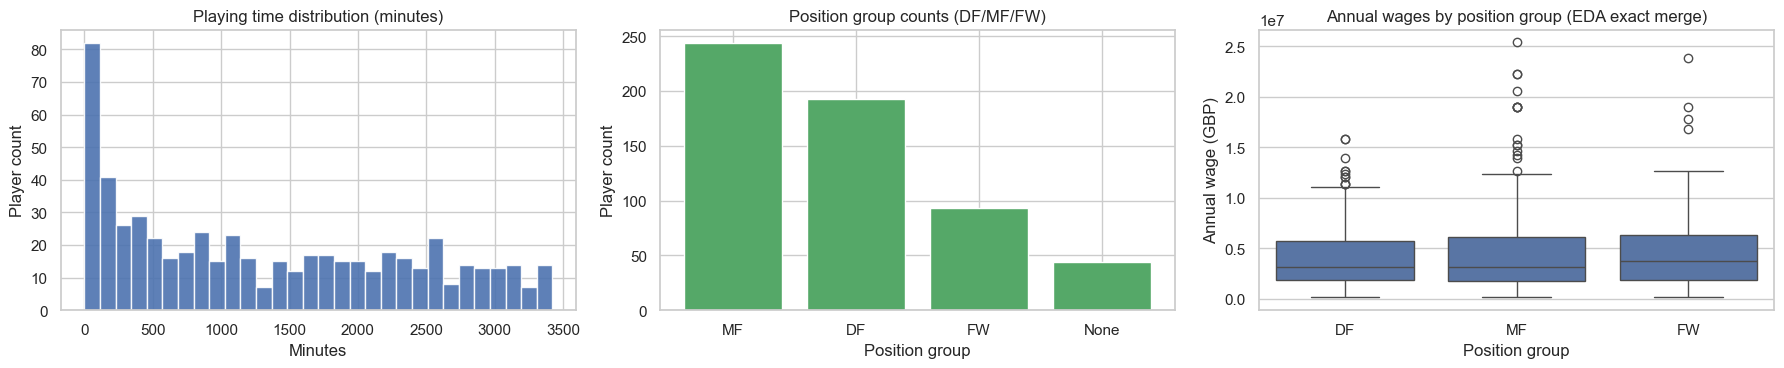

In [5]:
# Intent: quick sanity checks on playing time, position distribution, and salary distribution.

# Resolve common column name variants from different Kaggle/FBRef exports.
COL_ALIASES = {
    "player": ["player"],
    "pos": ["pos", "position"],
    "squad": ["squad", "team"],
    "minutes": ["minutes", "min", "playing_time_min", "playing_time_minute", "playing_time_min"],
}


def resolve_col(df: pd.DataFrame, canonical: str, *, required: bool = True) -> Optional[str]:
    candidates = COL_ALIASES.get(canonical, [canonical])
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(
            f"Could not find required column '{canonical}'. Tried: {candidates}. "
            f"Available: {df.columns.tolist()}"
        )
    return None


def _eda_pos_group(pos_raw: str) -> Optional[str]:
    """Intent: for EDA only, coarsen positions into DF/MF/FW and drop GK."""
    s = str(pos_raw).strip().upper()
    if not s:
        return None
    first = s.split(",")[0].strip()
    if "GK" in first:
        return None
    if first in {"AM", "DM", "CM"}:
        return "MF"
    if first.startswith("FW") or first == "F":
        return "FW"
    if first.startswith("MF") or first == "M":
        return "MF"
    if first.startswith("DF") or first == "D":
        return "DF"
    # If already one of the groups.
    if first in {"FW", "MF", "DF"}:
        return first
    return None


def _normalize_name_for_eda(s: str) -> str:
    """Intent: lightweight name normalization for EDA exact merge only."""
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


player_col = resolve_col(stats_raw, "player")
pos_col = resolve_col(stats_raw, "pos")
minutes_col = resolve_col(stats_raw, "minutes")

_stats_minutes = pd.to_numeric(stats_raw[minutes_col], errors="coerce")
_stats_pos_group = stats_raw[pos_col].map(_eda_pos_group)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot 1: minutes histogram
axes[0].hist(_stats_minutes.dropna(), bins=30, color="#4C72B0", alpha=0.9)
axes[0].set_title("Playing time distribution (minutes)")
axes[0].set_xlabel("Minutes")
axes[0].set_ylabel("Player count")

# Plot 2: position counts (coarsened to DF/MF/FW)
pos_counts = _stats_pos_group.value_counts(dropna=False)
axes[1].bar(pos_counts.index.astype(str), pos_counts.values, color="#55A868")
axes[1].set_title("Position group counts (DF/MF/FW)")
axes[1].set_xlabel("Position group")
axes[1].set_ylabel("Player count")

# Plot 3 (required): boxplot of wages by position group
# Intent: this is EDA-only and uses an exact-name merge; the full exact+fuzzy merge is done later.
_tmp_stats = stats_raw[[player_col, pos_col]].copy()
_tmp_stats["player_norm"] = _tmp_stats[player_col].map(_normalize_name_for_eda)
_tmp_stats["pos_group"] = _tmp_stats[pos_col].map(_eda_pos_group)

_tmp_salary = salary_raw[["player", "annual_wage_gbp"]].copy()
_tmp_salary["player_norm"] = _tmp_salary["player"].map(_normalize_name_for_eda)

_tmp_merged = _tmp_stats.merge(_tmp_salary[["player_norm", "annual_wage_gbp"]], on="player_norm", how="inner")
_tmp_merged = _tmp_merged.dropna(subset=["pos_group", "annual_wage_gbp"])

sns.boxplot(
    data=_tmp_merged,
    x="pos_group",
    y="annual_wage_gbp",
    order=["DF", "MF", "FW"],
    ax=axes[2],
)
axes[2].set_title("Annual wages by position group (EDA exact merge)")
axes[2].set_xlabel("Position group")
axes[2].set_ylabel("Annual wage (GBP)")

plt.tight_layout()
plt.show()


In [6]:
# Intent: clean the stats data and enforce the project constraints.

stats = stats_raw.copy()

# Resolve key columns.
player_col = resolve_col(stats, "player")
pos_col = resolve_col(stats, "pos")
squad_col = resolve_col(stats, "squad", required=False) or "squad"
minutes_col = resolve_col(stats, "minutes")

# 1) Filter out rows where pos contains GK (case-insensitive)
stats = stats[~stats[pos_col].astype(str).str.contains("GK", case=False, na=False)].copy()

# 2) Filter out FBRef header repeat rows
stats = stats[stats[player_col].astype(str).str.strip() != "Player"].copy()

# 3) Standardize pos to FW/MF/DF

def standardize_pos(pos_raw: str) -> Optional[str]:
    s = str(pos_raw).strip().upper()
    if not s:
        return None
    first = s.split(",")[0].strip()
    if "GK" in first:
        return None
    if first in {"AM", "DM", "CM"}:
        return "MF"
    if first.startswith("FW") or first == "F":
        return "FW"
    if first.startswith("MF") or first == "M":
        return "MF"
    if first.startswith("DF") or first == "D":
        return "DF"
    if first in {"FW", "MF", "DF"}:
        return first
    return None


stats["pos"] = stats[pos_col].map(standardize_pos)
stats = stats.dropna(subset=["pos"]).copy()

# 4) Cast numeric columns to float (coerce errors to NaN)
# Intent: avoid hardcoding an exhaustive numeric list; coerce non-identifiers.
identifier_like = {player_col, pos_col, "pos", squad_col, "squad", "nationality", "nation"}
for c in stats.columns:
    if c in identifier_like:
        continue
    stats[c] = pd.to_numeric(stats[c], errors="coerce")

# Keep canonical squad column name if present.
if squad_col in stats.columns and squad_col != "squad":
    stats = stats.rename(columns={squad_col: "squad"})

# Keep canonical player column name if present.
if player_col in stats.columns and player_col != "player":
    stats = stats.rename(columns={player_col: "player"})

# Keep canonical minutes column name if present.
if minutes_col in stats.columns and minutes_col != "minutes":
    stats = stats.rename(columns={minutes_col: "minutes"})

# 5) Drop players with minutes < threshold
stats = stats[stats["minutes"].fillna(0) >= CONFIG["min_minutes"]].copy()

# 6) Drop columns with > 40% missing values
missing_frac = stats.isna().mean()
drop_cols = missing_frac[missing_frac > 0.40].index.tolist()
stats = stats.drop(columns=drop_cols)

# 7) Impute remaining NaNs with column median within position group
# Intent: keep position-specific typical values.
num_cols = stats.select_dtypes(include=["number"]).columns.tolist()
for pos in ["FW", "MF", "DF"]:
    mask = stats["pos"] == pos
    if mask.sum() == 0:
        continue
    medians = stats.loc[mask, num_cols].median(numeric_only=True)
    stats.loc[mask, num_cols] = stats.loc[mask, num_cols].fillna(medians)

# 8) Deduplicate transferred players: keep row with most minutes
# Intent: if a player appears for multiple squads, keep the most representative row.
stats = stats.sort_values("minutes", ascending=False)
stats = stats.drop_duplicates(subset=["player"], keep="first").reset_index(drop=True)

print(f"Rows after cleaning: {len(stats):,}")
print("Position counts after cleaning:")
print(stats["pos"].value_counts())

stats.head()


Rows after cleaning: 366
Position counts after cleaning:
pos
MF    181
DF    136
FW     49
Name: count, dtype: int64


,rk,player,nation,pos,squad,age,born,playing_time_mp,playing_time_starts,minutes,...,performance_g_pk,performance_pk,performance_pkatt,performance_crdy,performance_crdr,per_90_minutes_gls,per_90_minutes_ast,per_90_minutes_g_a,per_90_minutes_g_pk,per_90_minutes_g_a_pk
0,106,Nathan Collins,ie IRL,DF,Brentford,23.0,2001.0,38,38,3420,...,2,0,0,5,0,0.05,0.08,0.13,0.05,0.13
1,341,Bryan Mbeumo,cm CMR,MF,Brentford,24.0,1999.0,38,38,3414,...,15,5,6,3,0,0.53,0.18,0.71,0.40,0.58
2,449,Mohamed Salah,eg EGY,MF,Liverpool,32.0,1992.0,38,38,3371,...,20,9,9,1,0,0.77,0.48,1.25,0.53,1.01
3,80,Moisés Caicedo,ec ECU,MF,Chelsea,22.0,2001.0,38,38,3351,...,1,0,0,11,0,0.03,0.05,0.08,0.03,0.08
4,285,Max Kilman,eng ENG,DF,West Ham United,27.0,1997.0,38,38,3348,...,0,0,0,5,0,0.00,0.03,0.03,0.00,0.03


In [7]:
# Intent: merge salaries to cleaned stats using exact match first, then fuzzy matching for remaining.


def normalize_name(s: str) -> str:
    s = "" if s is None else str(s)
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.combining(ch))
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s


stats_m = stats.copy()
salary_m = salary_raw.copy()

stats_m["player_norm"] = stats_m["player"].map(normalize_name)
salary_m["player_norm"] = salary_m["player"].map(normalize_name)

# 1) Exact merge on normalized player name
merged = stats_m.merge(
    salary_m[["player_norm", "squad", "weekly_wage_gbp", "annual_wage_gbp"]],
    on="player_norm",
    how="left",
    suffixes=("", "_salary"),
)

exact_matched_mask = merged["annual_wage_gbp"].notna()

# 2) Fuzzy match remaining players
unmatched = merged.loc[~exact_matched_mask, ["player", "player_norm", "pos", "squad"]].copy()
salary_choices = salary_m["player_norm"].dropna().unique().tolist()

fuzzy_best = []
for pn in unmatched["player_norm"].tolist():
    res = process.extractOne(
        pn,
        salary_choices,
        scorer=fuzz.token_sort_ratio,
        score_cutoff=CONFIG["fuzzy_threshold"],
    )
    if res is None:
        fuzzy_best.append(None)
    else:
        match_name, _, _ = res
        fuzzy_best.append(match_name)

unmatched["player_norm_fuzzy"] = fuzzy_best

# Join salary info via fuzzy match and fill only where exact is missing.
fuzzy_salary = unmatched.dropna(subset=["player_norm_fuzzy"]).merge(
    salary_m[["player_norm", "weekly_wage_gbp", "annual_wage_gbp", "squad"]],
    left_on="player_norm_fuzzy",
    right_on="player_norm",
    how="left",
    suffixes=("", "_salary"),
)

# Build lookup: original (stats) player_norm -> fuzzy salary columns
# Intent: pandas merge only suffixes overlapping *non-key* columns, so the original
# unmatched['player_norm'] remains named 'player_norm' (not 'player_norm_x').
fuzzy_salary_lookup = fuzzy_salary.set_index("player_norm")[[
    "weekly_wage_gbp",
    "annual_wage_gbp",
    "squad_salary",
]]

# Apply fills
merged = merged.set_index("player_norm")
needs_fill = merged["annual_wage_gbp"].isna()
fill_idx = merged.index[needs_fill & merged.index.isin(fuzzy_salary_lookup.index)]

merged.loc[fill_idx, "weekly_wage_gbp"] = fuzzy_salary_lookup.loc[fill_idx, "weekly_wage_gbp"]
merged.loc[fill_idx, "annual_wage_gbp"] = fuzzy_salary_lookup.loc[fill_idx, "annual_wage_gbp"]
merged.loc[fill_idx, "squad_salary"] = fuzzy_salary_lookup.loc[fill_idx, "squad_salary"]

merged = merged.reset_index(drop=False)

# 3) Merge stats reporting
n_total = len(stats_m)
exact_count = int(exact_matched_mask.sum())
fuzzy_count = int(merged["annual_wage_gbp"].notna().sum() - exact_count)
unmatched_count = int(n_total - exact_count - fuzzy_count)

print(f"Total players before merge: {n_total}")
print(f"Matched exact: {exact_count}")
print(f"Matched fuzzy: {fuzzy_count}")
print(f"Unmatched: {unmatched_count}")

unmatched_players = merged.loc[merged["annual_wage_gbp"].isna(), ["player", "pos", "squad"]]
print("\nUnmatched players (all):")
print(unmatched_players.to_string(index=False))

unmatched_rate = unmatched_count / max(n_total, 1)
if unmatched_rate > 0.25:
    print(
        f"WARNING: High unmatched rate ({unmatched_rate:.1%}). "
        "Consider reviewing name normalization or salary source coverage."
    )

# 4) Drop players with no salary match (cannot label them)
merged = merged.dropna(subset=["annual_wage_gbp"]).copy()
print(f"Rows after dropping unmatched salaries: {len(merged):,}")

merged.head()


Total players before merge: 366
Matched exact: 358
Matched fuzzy: 2
Unmatched: 6

Unmatched players (all):
                   player pos             squad
Victor Bernth Kristiansen  DF    Leicester City
              Álex Moreno  DF Nottingham Forest
           Oliver Scarles  MF   West Ham United
             Ross Barkley  MF       Aston Villa
    Abdul Fatawu Issahaku  MF    Leicester City
            Nico O’Reilly  DF   Manchester City
Rows after dropping unmatched salaries: 360


,player_norm,rk,player,nation,pos,squad,age,born,playing_time_mp,playing_time_starts,...,performance_crdy,performance_crdr,per_90_minutes_gls,per_90_minutes_ast,per_90_minutes_g_a,per_90_minutes_g_pk,per_90_minutes_g_a_pk,squad_salary,weekly_wage_gbp,annual_wage_gbp
0,nathan collins,106,Nathan Collins,ie IRL,DF,Brentford,23.0,2001.0,38,38,...,5,0,0.05,0.08,0.13,0.05,0.13,Brentford,36638.0,1905153.0
1,bryan mbeumo,341,Bryan Mbeumo,cm CMR,MF,Brentford,24.0,1999.0,38,38,...,3,0,0.53,0.18,0.71,0.40,0.58,Brentford,54956.0,2857730.0
2,mohamed salah,449,Mohamed Salah,eg EGY,MF,Liverpool,32.0,1992.0,38,38,...,1,0,0.77,0.48,1.25,0.53,1.01,Liverpool,427438.0,22226790.0
3,moises caicedo,80,Moisés Caicedo,ec ECU,MF,Chelsea,22.0,2001.0,38,38,...,11,0,0.03,0.05,0.08,0.03,0.08,Chelsea,183188.0,9525767.0
4,max kilman,285,Max Kilman,eng ENG,DF,West Ham United,27.0,1997.0,38,38,...,5,0,0.00,0.03,0.03,0.00,0.03,West Ham,122125.0,6350511.0


In [8]:
# Intent: create per-position salary tier labels using within-position percentiles.

def fmt_gbp(x: float) -> str:
    try:
        return f"£{int(round(float(x))):,}"
    except (TypeError, ValueError):
        return "£NA"


merged_l = merged.copy()

# Average salary per position (requested).
avg_salary = (
    merged_l.groupby("pos", as_index=False)["annual_wage_gbp"]
    .mean()
    .rename(columns={"annual_wage_gbp": "avg_annual_wage_gbp"})
)
avg_salary["avg_annual_wage_gbp"] = avg_salary["avg_annual_wage_gbp"].map(fmt_gbp)
print("Average annual salary by position:")
display(avg_salary)

break_rows = []
for pos in ["FW", "MF", "DF"]:
    sub = merged_l.loc[merged_l["pos"] == pos, "annual_wage_gbp"].astype(float)
    if len(sub) == 0:
        continue
    q33 = np.nanpercentile(sub, 33)
    q66 = np.nanpercentile(sub, 66)
    break_rows.append({
        "Position": pos,
        "Low/Med Threshold": q33,
        "Med/High Threshold": q66,
    })

    def tier(w: float) -> int:
        if w < q33:
            return 0
        if w <= q66:
            return 1
        return 2

    merged_l.loc[merged_l["pos"] == pos, "salary_tier"] = merged_l.loc[
        merged_l["pos"] == pos, "annual_wage_gbp"
    ].astype(float).map(tier)

merged_l["salary_tier"] = merged_l["salary_tier"].astype(int)

label_map = {0: "Low", 1: "Medium", 2: "High"}
merged_l["salary_tier_label"] = merged_l["salary_tier"].map(label_map)

break_df = pd.DataFrame(break_rows)
if not break_df.empty:
    break_df["Low/Med Threshold"] = break_df["Low/Med Threshold"].map(fmt_gbp)
    break_df["Med/High Threshold"] = break_df["Med/High Threshold"].map(fmt_gbp)

print("Salary tier breakpoints by position (annual_wage_gbp):")
display(break_df)

merged_l[["player", "pos", "annual_wage_gbp", "salary_tier_label"]].head()


Average annual salary by position:


,pos,avg_annual_wage_gbp
0,DF,"£4,652,717"
1,FW,"£6,130,773"
2,MF,"£5,219,388"


Salary tier breakpoints by position (annual_wage_gbp):


,Position,Low/Med Threshold,Med/High Threshold
0,FW,"£3,759,503","£6,350,511"
1,MF,"£2,540,205","£5,080,409"
2,DF,"£2,681,379","£5,080,409"


,player,pos,annual_wage_gbp,salary_tier_label
0,Nathan Collins,DF,1905153.0,Low
1,Bryan Mbeumo,MF,2857730.0,Medium
2,Mohamed Salah,MF,22226790.0,High
3,Moisés Caicedo,MF,9525767.0,High
4,Max Kilman,DF,6350511.0,High


In [9]:
# Intent: build the model feature matrix using the current features PLUS cards and other
# available per-player performance fields from this dataset.
# We still exclude: player name, squad/team, nationality, and any wage columns.

# Column aliasing for common FBRef/Kaggle naming variants.
FEATURE_ALIASES = {
    # Playing time
    "minutes_90s": ["minutes_90s", "playing_time_90s"],
    "minutes": ["minutes", "min", "playing_time_min"],
    "games": ["games", "playing_time_mp"],
    "games_starts": ["games_starts", "playing_time_starts"],

    # Attacking output
    "goals": ["goals", "performance_gls"],
    "assists": ["assists", "performance_ast"],
    "goals_assists": ["goals_assists", "performance_g_a"],
    "goals_pens": ["goals_pens", "performance_g_pk"],
    "pens_made": ["pens_made", "performance_pk"],
    "pens_att": ["pens_att", "performance_pkatt"],

    # Discipline (requested)
    "yellow_cards": ["yellow_cards", "performance_crdy"],
    "red_cards": ["red_cards", "performance_crdr"],

    # Per-90 attacking rates
    "goals_per90": ["goals_per90", "per_90_minutes_gls", "per90_gls"],
    "assists_per90": ["assists_per90", "per_90_minutes_ast", "per90_ast"],
    "goals_assists_per90": ["goals_assists_per90", "per_90_minutes_g_a"],
    "goals_pens_per90": ["goals_pens_per90", "per_90_minutes_g_pk"],
    "goals_assists_pens_per90": ["goals_assists_pens_per90", "per_90_minutes_g_a_pk"],

    # Optional (if ever present)
    "xg_per90": ["xg_per90", "per_90_minutes_xg"],
    "xg_assist_per90": ["xg_assist_per90", "per_90_minutes_xg_ast"],
    "npxg_per90": ["npxg_per90", "per_90_minutes_npxg"],

    # Demographics
    "age": ["age"],
}


def resolve_feature_col_optional(df: pd.DataFrame, canonical: str) -> Optional[str]:
    for c in FEATURE_ALIASES.get(canonical, [canonical]):
        if c in df.columns:
            return c
    return None


def add_if_present(feat_dict: dict, df: pd.DataFrame, name: str, canonical: str) -> None:
    """Intent: add feature only if its source column exists."""
    col = resolve_feature_col_optional(df, canonical)
    if col is None:
        return
    feat_dict[name] = pd.to_numeric(df[col], errors="coerce").astype(float)


df = merged_l.copy()

# Must-have minimal set (so the model always runs).
col_minutes_90s = resolve_feature_col_optional(df, "minutes_90s")
col_goals_p90 = resolve_feature_col_optional(df, "goals_per90")
col_assists_p90 = resolve_feature_col_optional(df, "assists_per90")
col_age = resolve_feature_col_optional(df, "age")

missing_min_required = [
    k
    for k, v in {
        "minutes_90s": col_minutes_90s,
        "goals_per90": col_goals_p90,
        "assists_per90": col_assists_p90,
        "age": col_age,
    }.items()
    if v is None
]
if missing_min_required:
    raise KeyError(
        "Missing required columns for feature engineering: "
        f"{missing_min_required}. Available: {df.columns.tolist()}"
    )

# Cast/clean age.
df["age_int"] = pd.to_numeric(df[col_age], errors="coerce").round().astype("Int64")

features = {
    "minutes_90s": pd.to_numeric(df[col_minutes_90s], errors="coerce").astype(float),
    "goals_per90": pd.to_numeric(df[col_goals_p90], errors="coerce").astype(float),
    "assists_per90": pd.to_numeric(df[col_assists_p90], errors="coerce").astype(float),
    "age": df["age_int"].astype(float),
}

# Add extra available performance fields (including cards).
add_if_present(features, df, "minutes", "minutes")
add_if_present(features, df, "games", "games")
add_if_present(features, df, "games_starts", "games_starts")
add_if_present(features, df, "goals", "goals")
add_if_present(features, df, "assists", "assists")
add_if_present(features, df, "goals_assists", "goals_assists")
add_if_present(features, df, "goals_pens", "goals_pens")
add_if_present(features, df, "pens_made", "pens_made")
add_if_present(features, df, "pens_att", "pens_att")
add_if_present(features, df, "yellow_cards", "yellow_cards")
add_if_present(features, df, "red_cards", "red_cards")
add_if_present(features, df, "goals_assists_per90", "goals_assists_per90")
add_if_present(features, df, "goals_pens_per90", "goals_pens_per90")
add_if_present(features, df, "goals_assists_pens_per90", "goals_assists_pens_per90")

# Optional xG features (only if they exist in some future file).
add_if_present(features, df, "xg_per90", "xg_per90")
add_if_present(features, df, "xg_assist_per90", "xg_assist_per90")
add_if_present(features, df, "npxg_per90", "npxg_per90")

X_base = pd.DataFrame(features)

# One-hot encode position as requested.
X_pos = pd.get_dummies(df["pos"], prefix="pos")
X = pd.concat([X_base, X_pos], axis=1)

FEATURE_COLS = X.columns.tolist()
y = df["salary_tier"].astype(int)

print(f"Using {len(FEATURE_COLS)} features:")
print(FEATURE_COLS)
display(X.head())


Using 21 features:
['minutes_90s', 'goals_per90', 'assists_per90', 'age', 'minutes', 'games', 'games_starts', 'goals', 'assists', 'goals_assists', 'goals_pens', 'pens_made', 'pens_att', 'yellow_cards', 'red_cards', 'goals_assists_per90', 'goals_pens_per90', 'goals_assists_pens_per90', 'pos_DF', 'pos_FW', 'pos_MF']


,minutes_90s,goals_per90,assists_per90,age,minutes,games,games_starts,goals,assists,goals_assists,...,pens_made,pens_att,yellow_cards,red_cards,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,pos_DF,pos_FW,pos_MF
0,38.0,0.05,0.08,23.0,3420.0,38.0,38.0,2.0,3.0,5.0,...,0.0,0.0,5.0,0.0,0.13,0.05,0.13,True,False,False
1,37.9,0.53,0.18,24.0,3414.0,38.0,38.0,20.0,7.0,27.0,...,5.0,6.0,3.0,0.0,0.71,0.40,0.58,False,False,True
2,37.5,0.77,0.48,32.0,3371.0,38.0,38.0,29.0,18.0,47.0,...,9.0,9.0,1.0,0.0,1.25,0.53,1.01,False,False,True
3,37.2,0.03,0.05,22.0,3351.0,38.0,38.0,1.0,2.0,3.0,...,0.0,0.0,11.0,0.0,0.08,0.03,0.08,False,False,True
4,37.2,0.00,0.03,27.0,3348.0,38.0,38.0,0.0,1.0,1.0,...,0.0,0.0,5.0,0.0,0.03,0.00,0.03,True,False,False


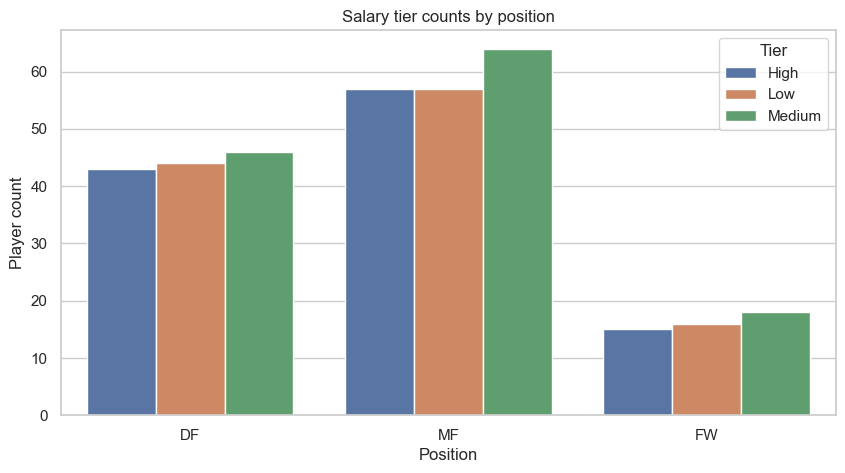

In [10]:
# Intent: visualize class balance across position groups.

balance = df.groupby(["pos", "salary_tier_label"]).size().reset_index(name="count")

plt.figure(figsize=(10, 5))
sns.barplot(data=balance, x="pos", y="count", hue="salary_tier_label", order=["DF", "MF", "FW"])
plt.title("Salary tier counts by position")
plt.xlabel("Position")
plt.ylabel("Player count")
plt.legend(title="Tier")
plt.show()


In [11]:
# Intent: create a stratified split that preserves position+tier structure.

stratify_key = df["pos"].astype(str) + "_" + df["salary_tier"].astype(str)

X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X,
    y,
    df[["player", "squad", "pos", "annual_wage_gbp", "salary_tier_label"]],
    test_size=0.2,
    random_state=CONFIG["random_state"],
    stratify=stratify_key,
)

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")


Train size: 288
Test size:  72


In [12]:
# Intent: baseline model (Logistic Regression) with CV on training set.

stratify_key_train = df_train["pos"].astype(str) + "_" + y_train.astype(str)

cv = StratifiedKFold(
    n_splits=CONFIG["cv_folds"],
    shuffle=True,
    random_state=CONFIG["random_state"],
)
cv_splits = list(cv.split(X_train, stratify_key_train))


def eval_with_cv(name: str, pipeline: Pipeline) -> dict:
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv_splits,
        scoring="f1_macro",
        n_jobs=-1,
    )
    print(f"{name} CV macro F1: {scores.mean():.3f} ± {scores.std():.3f}")

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    test_macro_f1 = f1_score(y_test, y_pred, average="macro")
    print(f"{name} test macro F1: {test_macro_f1:.3f}")

    return {
        "model": name,
        "cv_mean_macro_f1": float(scores.mean()),
        "cv_std_macro_f1": float(scores.std()),
        "test_macro_f1": float(test_macro_f1),
        "pipeline": pipeline,
    }


lr_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                max_iter=1000,
                random_state=CONFIG["random_state"]
            ),
        ),
    ]
)

lr_results = eval_with_cv("Logistic Regression", lr_pipe)


Logistic Regression CV macro F1: 0.411 ± 0.063
Logistic Regression test macro F1: 0.357


In [13]:
# Intent: Random Forest model with CV on training set.

rf_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=CONFIG["random_state"],
                n_jobs=-1,
            ),
        ),
    ]
)

rf_results = eval_with_cv("Random Forest", rf_pipe)


Random Forest CV macro F1: 0.417 ± 0.054
Random Forest test macro F1: 0.372


In [14]:
# Intent: XGBoost model with CV on training set.

xgb_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "clf",
            XGBClassifier(
                use_label_encoder=False,
                eval_metric="mlogloss",
                random_state=CONFIG["random_state"],
                n_estimators=200,
                n_jobs=-1,
            ),
        ),
    ]
)

xgb_results = eval_with_cv("XGBoost", xgb_pipe)


XGBoost CV macro F1: 0.393 ± 0.009


c:\Users\yashy\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [18:09:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost test macro F1: 0.407


In [15]:
# Intent: compare CV performance across models.

cv_summary = pd.DataFrame(
    [
        {k: v for k, v in lr_results.items() if k != "pipeline"},
        {k: v for k, v in rf_results.items() if k != "pipeline"},
        {k: v for k, v in xgb_results.items() if k != "pipeline"},
    ]
)

cv_summary["cv_macro_f1"] = cv_summary.apply(
    lambda r: f"{r['cv_mean_macro_f1']:.3f} ± {r['cv_std_macro_f1']:.3f}", axis=1
)

cv_summary_display = cv_summary[["model", "cv_macro_f1", "test_macro_f1"]].copy()

print("CV Results (training set, macro F1):")
display(cv_summary_display)

best_model_name = cv_summary.sort_values("cv_mean_macro_f1", ascending=False).iloc[0]["model"]
print(f"Best model by mean CV macro F1: {best_model_name}")


CV Results (training set, macro F1):


,model,cv_macro_f1,test_macro_f1
0,Logistic Regression,0.411 ± 0.063,0.356740
1,Random Forest,0.417 ± 0.054,0.371821
2,XGBoost,0.393 ± 0.009,0.406763


Best model by mean CV macro F1: Random Forest


In [16]:
# Intent: hyperparameter tuning on the best CV model (RF or XGBoost).

model_results_map = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "XGBoost": xgb_results,
}

best_results = model_results_map[best_model_name]
best_pipe = best_results["pipeline"]

# Use cv=5 as required, stratifying by pos+tier within training.
cv_tune = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=CONFIG["random_state"],
)
cv_tune_splits = list(cv_tune.split(X_train, stratify_key_train))

search = None
if best_model_name == "Random Forest":
    param_distributions = {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 5, 10, 15],
        "clf__min_samples_leaf": [1, 2, 4],
    }
    search = RandomizedSearchCV(
        best_pipe,
        param_distributions=param_distributions,
        n_iter=20,
        cv=cv_tune_splits,
        scoring="f1_macro",
        random_state=CONFIG["random_state"],
        n_jobs=-1,
        verbose=1,
    )
elif best_model_name == "XGBoost":
    param_distributions = {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1, 0.2],
        "clf__max_depth": [3, 5, 7],
        "clf__subsample": [0.7, 0.9],
    }
    search = RandomizedSearchCV(
        best_pipe,
        param_distributions=param_distributions,
        n_iter=20,
        cv=cv_tune_splits,
        scoring="f1_macro",
        random_state=CONFIG["random_state"],
        n_jobs=-1,
        verbose=1,
    )
else:
    # Intent: you only specified tuning grids for RF and XGBoost.
    print(
        "Best model is Logistic Regression. Hyperparameter tuning is skipped "
        "because the assignment spec only defines RandomizedSearchCV grids for "
        "Random Forest and XGBoost."
    )

if search is not None:
    search.fit(X_train, y_train)
    tuned_model = search.best_estimator_
    print("Best params:")
    print(search.best_params_)
    print(f"Best CV macro F1: {search.best_score_:.3f}")
else:
    tuned_model = best_pipe.fit(X_train, y_train)


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params:
{'clf__n_estimators': 300, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Best CV macro F1: 0.447


Classification report (test set):
              precision    recall  f1-score   support

         Low       0.29      0.35      0.31        23
      Medium       0.33      0.31      0.32        26
        High       0.45      0.39      0.42        23

    accuracy                           0.35        72
   macro avg       0.36      0.35      0.35        72
weighted avg       0.36      0.35      0.35        72



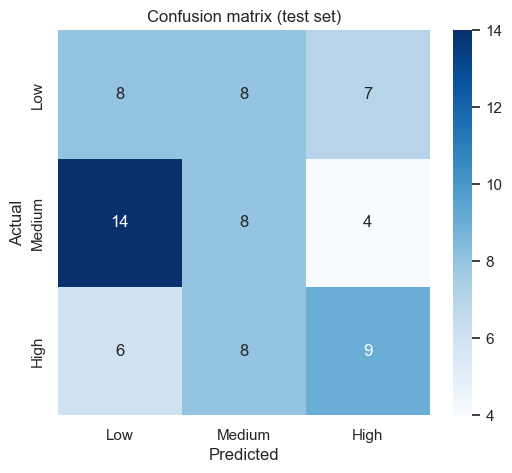

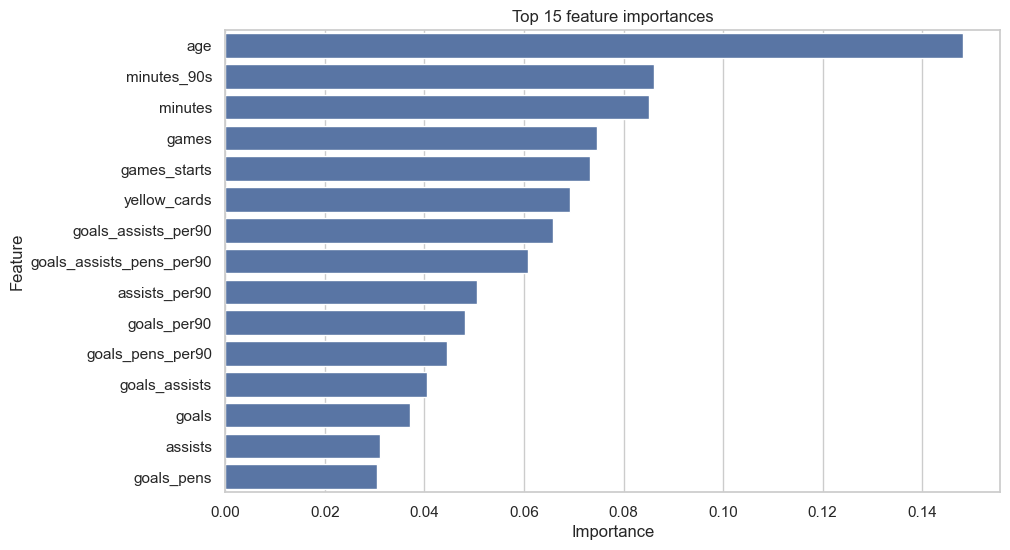

Top ~10 features by position (RandomForest importances):

Position: DF


,importance
age,0.177364
games,0.102654
minutes,0.102391
minutes_90s,0.098763
yellow_cards,0.092941
games_starts,0.091484
goals_assists_pens_per90,0.055740
goals_assists_per90,0.052846
assists_per90,0.040595
goals_pens_per90,0.036943



Position: MF


,importance
age,0.129413
minutes,0.084357
minutes_90s,0.083139
goals_assists_per90,0.077185
goals_assists_pens_per90,0.072922
games,0.071584
games_starts,0.067647
yellow_cards,0.060418
assists_per90,0.059027
goals_per90,0.057801



Position: FW


,importance
goals_assists_pens_per90,0.084012
games,0.075296
assists_per90,0.070729
age,0.070063
minutes_90s,0.067295
goals_assists_per90,0.063596
goals_pens_per90,0.063223
minutes,0.061086
goals_assists,0.060495
goals_per90,0.057969


## Interpretation

Because the dataset is missing xG/progression/possession/defensive event stats, the model leans heavily on minutes played plus goals/assists/cards and related rates. That makes the signal **stronger for attackers** and typically **weaker for defenders**, where 'clean play' (cards) is only a partial proxy for defensive value.

The **Medium** tier is often hardest because it overlaps with both Low and High wages.

In this run, the lowest recall class is **Medium** on the held-out test set.

In [17]:
# Intent: final evaluation on held-out test set for the tuned/best model.

from IPython.display import Markdown, display

label_map = {0: "Low", 1: "Medium", 2: "High"}
labels_order = [0, 1, 2]
label_names = [label_map[i] for i in labels_order]

y_test_pred = tuned_model.predict(X_test)

print("Classification report (test set):")
print(classification_report(y_test, y_test_pred, target_names=label_names))

cm = confusion_matrix(y_test, y_test_pred, labels=labels_order)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion matrix (test set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance / coefficients
feature_names = FEATURE_COLS
clf = tuned_model.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
    topk = importances.head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=topk.values, y=topk.index, orient="h")
    plt.title("Top 15 feature importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

elif hasattr(clf, "coef_"):
    coefs = clf.coef_  # shape: (n_classes, n_features)
    for i, class_name in enumerate(label_names):
        s = pd.Series(coefs[i], index=feature_names).sort_values(key=lambda x: np.abs(x), ascending=False).head(15)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=s.values, y=s.index, orient="h")
        plt.title(f"Top 15 coefficients (Logistic Regression) — class: {class_name}")
        plt.xlabel("Coefficient")
        plt.ylabel("Feature")
        plt.show()

else:
    print("Model does not expose feature importances or coefficients.")

# --- Per-position top features (requested) ---
# Intent: show which features matter most within each position group.
# We fit a simple RandomForest per position (tree models expose importances).

pos_top_features = {}
for pos in ["DF", "MF", "FW"]:
    mask_train = df_train["pos"].values == pos
    if mask_train.sum() < 20:
        continue

    Xp = X_train.loc[mask_train].copy()
    yp = y_train.loc[mask_train].copy()

    # Drop position one-hots for per-position models (constant within group).
    drop_pos_cols = [c for c in Xp.columns if c.startswith("pos_")]
    Xp = Xp.drop(columns=drop_pos_cols, errors="ignore")

    rf_local = RandomForestClassifier(
        n_estimators=300,
        random_state=CONFIG["random_state"],
        n_jobs=-1,
    )
    rf_local.fit(Xp, yp)

    imp = pd.Series(rf_local.feature_importances_, index=Xp.columns).sort_values(ascending=False)
    pos_top_features[pos] = imp.head(10)

print("Top ~10 features by position (RandomForest importances):")
for pos, series in pos_top_features.items():
    print(f"\nPosition: {pos}")
    display(series.to_frame(name="importance"))

# Interpretation markdown (required)
# Intent: identify the hardest tier/position to classify from the confusion matrix.
per_class_recall = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
hardest_class_idx = int(np.argmin(per_class_recall))
hardest_class = label_names[hardest_class_idx]

interpretation = (
    "## Interpretation\n\n"
    "Because the dataset is missing xG/progression/possession/defensive event stats, "
    "the model leans heavily on minutes played plus goals/assists/cards and related rates. "
    "That makes the signal **stronger for attackers** and typically **weaker for defenders**, "
    "where 'clean play' (cards) is only a partial proxy for defensive value.\n\n"
    "The **Medium** tier is often hardest because it overlaps with both Low and High wages.\n\n"
    f"In this run, the lowest recall class is **{hardest_class}** on the held-out test set."
)

display(Markdown(interpretation))


In [18]:
# Intent: produce exportable results and inspect confident correct/wrong predictions.

proba = None
if hasattr(tuned_model, "predict_proba"):
    proba = tuned_model.predict_proba(X_test)

pred_labels = pd.Series(y_test_pred).map(label_map)
actual_labels = pd.Series(y_test).map(label_map)

results = df_test.copy().reset_index(drop=True)
results["salary_tier_actual"] = actual_labels.values
results["salary_tier_predicted"] = pred_labels.values
results["correct"] = results["salary_tier_actual"] == results["salary_tier_predicted"]

# Sort by pos then actual tier label
results["salary_tier_actual"] = pd.Categorical(results["salary_tier_actual"], categories=["Low", "Medium", "High"], ordered=True)
results = results.sort_values(["pos", "salary_tier_actual"]).reset_index(drop=True)

# Export
out_path = CONFIG["output_path"]
os.makedirs(os.path.dirname(out_path), exist_ok=True)

# Overall test-set accuracy for the selected model.
model_accuracy = float((y_test_pred == y_test).mean())

results_out = results[[
    "player",
    "squad",
    "pos",
    "annual_wage_gbp",
    "salary_tier_actual",
    "salary_tier_predicted",
    "correct",
]].copy()

# Confidence analysis (add confidence before footer row to keep lengths aligned)
if proba is not None:
    max_prob = proba.max(axis=1)
    results_out["max_prob"] = max_prob

    most_conf_correct = results_out[results_out["correct"]].sort_values("max_prob", ascending=False).head(10)
    most_conf_wrong = results_out[~results_out["correct"]].sort_values("max_prob", ascending=False).head(10)

    print("\n10 most confidently correct predictions:")
    display(most_conf_correct[["player", "pos", "salary_tier_actual", "salary_tier_predicted", "max_prob"]])

    print("\n10 most confidently wrong predictions:")
    display(most_conf_wrong[["player", "pos", "salary_tier_actual", "salary_tier_predicted", "max_prob"]])
else:
    print("Model does not support predict_proba; skipping confidence tables.")

# Append a footer row with overall model accuracy (instead of adding a new column).
footer_data = {
    "player": "MODEL_ACCURACY",
    "squad": "",
    "pos": "",
    "annual_wage_gbp": "",
    "salary_tier_actual": f"{model_accuracy:.3f}",
    "salary_tier_predicted": "",
    "correct": "",
}
if "max_prob" in results_out.columns:
    footer_data["max_prob"] = ""

accuracy_row = pd.DataFrame([footer_data])
results_out = pd.concat([results_out, accuracy_row], ignore_index=True)

results_out.to_csv(out_path, index=False)
print(f"Exported: {out_path}")
print(f"Model accuracy (test set): {model_accuracy:.3f}")



10 most confidently correct predictions:


,player,pos,salary_tier_actual,salary_tier_predicted,max_prob
69,Dominik Szoboszlai,MF,High,High,0.615050
5,Jacob Greaves,DF,Low,Low,0.603738
63,Youri Tielemans,MF,High,High,0.569583
37,Omari Hutchinson,MF,Low,Low,0.566097
34,Timo Werner,FW,High,High,0.557215
20,Trent Alexander-Arnold,DF,High,High,0.526572
58,Sander Berge,MF,Medium,Medium,0.526278
45,Julio Enciso,MF,Low,Low,0.509772
26,Max Kilman,DF,High,High,0.506167
51,Carlos Soler,MF,Medium,Medium,0.482827



10 most confidently wrong predictions:


,player,pos,salary_tier_actual,salary_tier_predicted,max_prob
12,Destiny Udogie,DF,Medium,Low,0.796824
11,Marc Guéhi,DF,Medium,Low,0.789824
27,Liam Delap,FW,Low,Medium,0.713821
19,Radu Drăgușin,DF,High,Low,0.699530
67,Jorginho,MF,High,Medium,0.691676
50,Adama Traoré,MF,Medium,Low,0.672709
46,Kyle Walker-Peters,MF,Low,High,0.657048
61,Jadon Sancho,MF,High,Low,0.621405
55,Noni Madueke,MF,Medium,Low,0.616579
39,Vitaly Janelt,MF,Low,High,0.609131


Exported: output/player_salary_classifications.csv
Model accuracy (test set): 0.347


## Limitations & next steps

- **Major feature gaps in the provided stats file**: This run has **no xG, no progressive carries/passes, no possession stats, and no defensive event stats**. As a result, the model relies mostly on minutes + goals/assists + age/pens, which is **much more informative for attackers than for defenders**.
- **Defenders will be harder**: Without progression/possession/defending signals, many DFs can look similar in the feature space even if their wages differ substantially.
- **Position ambiguity**: Players often appear as hybrid roles (e.g., `DF,MF`). We simplified to the first position token and mapped some variants to `MF`, which can introduce label noise.
- **Salary merge loss rate**: Even with normalization + fuzzy matching, the salary file can miss players or use different naming conventions, causing an unavoidable unmatched set that must be dropped (reducing training data and potentially biasing the sample).

**Next steps**
- Add richer player-level features (xG/xA, progressive actions, passing/possession, defensive events) from additional FBRef tables (still player-level, not squad-level aggregates).
- Improve name matching with squad constraints (e.g., only fuzzy-match within the same squad) to reduce false matches.
- Consider ordinal modeling (Low < Medium < High) to better reflect tier structure.
